In [1]:
import pandas as pd

df = pd.read_csv('/content/breast-cancer.csv')
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Task
Analyze the "breast-cancer.csv" dataset by building and evaluating Support Vector Machine (SVM) models with linear and RBF kernels. This includes data preprocessing, splitting the data, training and evaluating both models using accuracy, precision, recall, and F1-score. Visualize the decision boundaries after reducing data to two dimensions using PCA. Further, tune hyperparameters (C and gamma) for the RBF kernel SVM using GridSearchCV or RandomizedSearchCV, and evaluate the best model's robustness with K-fold cross-validation. Finally, summarize the findings, compare model performances, and discuss the effectiveness of SVM for breast cancer prediction.

## Load and Prepare Data

### Subtask:
Load the breast-cancer.csv dataset. Identify the features and the target variable ('diagnosis'). Convert the 'diagnosis' column into a numerical format (e.g., 0 for 'B' and 1 for 'M'). Handle any missing values if present. Scale the numerical features using a StandardScaler.


**Reasoning**:
The subtask requires separating the target variable ('diagnosis') from the features, converting the target variable into a numerical format (0 for 'B' and 1 for 'M'), and then checking for missing values in the dataset. This step will handle these initial data preparation tasks.



In [2]:
y = df['diagnosis'].map({'B': 0, 'M': 1})
X = df.drop(['id', 'diagnosis'], axis=1)

# Check for missing values
missing_values = X.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

Missing values per column:
 Series([], dtype: int64)


**Reasoning**:
As instructed by the subtask, the next step is to scale the numerical features in the DataFrame `X` using `StandardScaler` from `sklearn.preprocessing`. This will standardize the features by removing the mean and scaling to unit variance.



In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled_df.head())


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## Split Data

### Subtask:
Split the preprocessed dataset into training and testing sets to evaluate model performance on unseen data. A common split is 80% for training and 20% for testing.


**Reasoning**:
To split the preprocessed data into training and testing sets as instructed by the subtask, I will use the `train_test_split` function from `sklearn.model_selection`.



In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


## Train SVM with Linear Kernel

### Subtask:
Train a Support Vector Machine (SVM) classifier using a linear kernel on the training data. Evaluate its performance on the test set using metrics like accuracy, precision, recall, and F1-score.


**Reasoning**:
To begin training the Support Vector Machine (SVM) model with a linear kernel, I will import the necessary `SVC` class, instantiate it with the specified parameters, train it on the `X_train` and `y_train` datasets, and then use it to make predictions on the `X_test` dataset. After making predictions, I will import the required evaluation metrics from `sklearn.metrics` and calculate the accuracy, precision, recall, and F1-score for the linear SVM model.



In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Instantiate an SVC classifier with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Train the SVM model on the training data
svm_linear.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = svm_linear.predict(X_test)

# Calculate evaluation metrics
accuracy_linear = accuracy_score(y_test, y_pred_linear)
precision_linear = precision_score(y_test, y_pred_linear)
recall_linear = recall_score(y_test, y_pred_linear)
f1_linear = f1_score(y_test, y_pred_linear)

# Print the calculated metrics
print(f"Linear SVM Model Performance:")
print(f"Accuracy: {accuracy_linear:.4f}")
print(f"Precision: {precision_linear:.4f}")
print(f"Recall: {recall_linear:.4f}")
print(f"F1-Score: {f1_linear:.4f}")

Linear SVM Model Performance:
Accuracy: 0.9561
Precision: 0.9318
Recall: 0.9535
F1-Score: 0.9425


## Train SVM with RBF Kernel

### Subtask:
Train a Support Vector Machine (SVM) classifier using a Radial Basis Function (RBF) kernel on the training data. Evaluate its performance on the test set using metrics like accuracy, precision, recall, and F1-score.


**Reasoning**:
To address the subtask, I will instantiate an SVC classifier with an RBF kernel, train it on the training data, make predictions on the test set, and then calculate and print the required evaluation metrics (accuracy, precision, recall, and F1-score).



In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Instantiate an SVC classifier with an RBF kernel
svm_rbf = SVC(kernel='rbf', random_state=42)

# Train the SVM model on the training data
svm_rbf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rbf = svm_rbf.predict(X_test)

# Calculate evaluation metrics
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
precision_rbf = precision_score(y_test, y_pred_rbf)
recall_rbf = recall_score(y_test, y_pred_rbf)
f1_rbf = f1_score(y_test, y_pred_rbf)

# Print the calculated metrics
print(f"RBF SVM Model Performance:")
print(f"Accuracy: {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall: {recall_rbf:.4f}")
print(f"F1-Score: {f1_rbf:.4f}")

RBF SVM Model Performance:
Accuracy: 0.9737
Precision: 0.9762
Recall: 0.9535
F1-Score: 0.9647


## Visualize Decision Boundaries

### Subtask:
Apply Principal Component Analysis (PCA) to reduce the data to two dimensions. Then, plot the decision boundaries of both the linear and RBF kernel SVM models using these two principal components, clearly showing the separation of classes. Add legends to the visualization.


**Reasoning**:
To begin visualizing the decision boundaries, I need to apply Principal Component Analysis (PCA) to reduce the `X_scaled_df` dataset to two dimensions. This involves importing PCA, instantiating it with two components, and then fitting and transforming the data to create a new DataFrame `X_pca_df` with the principal components.



In [7]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Instantiate PCA with 2 components
pca = PCA(n_components=2)

# Fit PCA to the scaled features and transform them
X_pca = pca.fit_transform(X_scaled_df)

# Convert the PCA results into a DataFrame for easier handling
X_pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

display(X_pca_df.head())


,PC1,PC2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


**Reasoning**:
The next step is to split the PCA-transformed data into training and testing sets, train new SVM models with linear and RBF kernels on this 2D data, create a meshgrid for plotting, predict class labels across the meshgrid for both SVMs, and then visualize their decision boundaries along with the training data points.



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


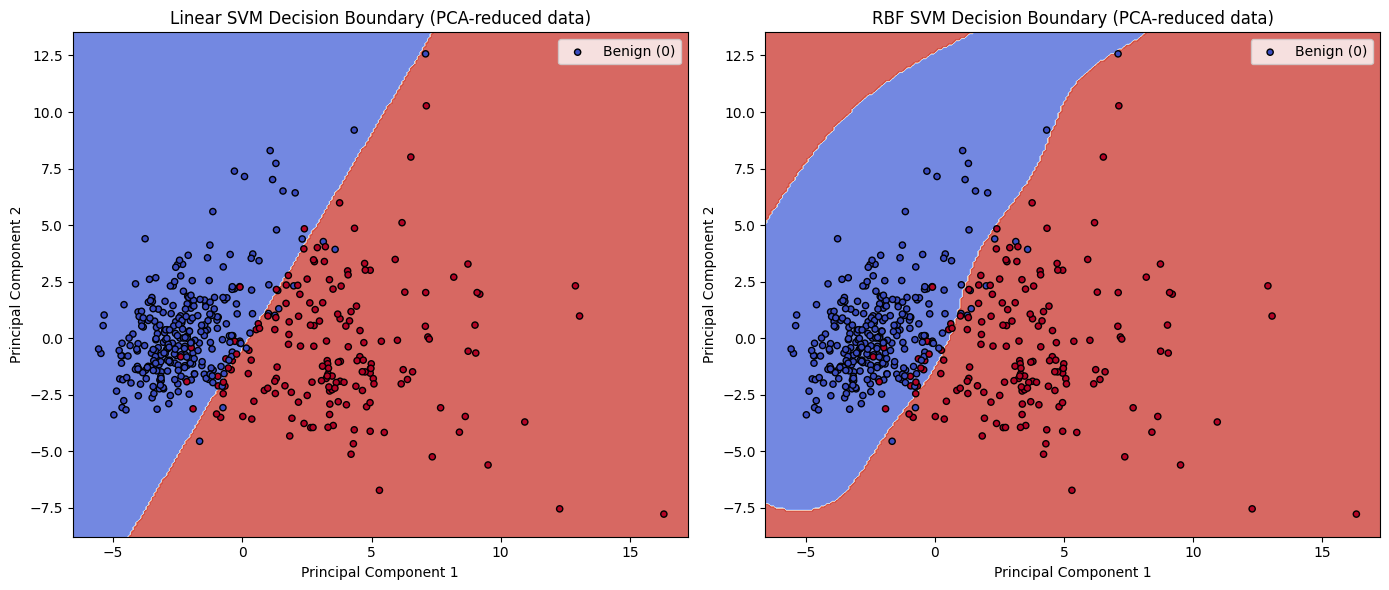

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Split the PCA-transformed data into training and testing sets
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca_df, y, test_size=0.2, random_state=42)

# Instantiate and train two new SVC classifiers on the 2D PCA data
svm_linear_pca = SVC(kernel='linear', random_state=42)
svm_linear_pca.fit(X_pca_train, y_pca_train)

svm_rbf_pca = SVC(kernel='rbf', random_state=42)
svm_rbf_pca.fit(X_pca_train, y_pca_train)

# Create a meshgrid to plot decision boundaries
x_min, x_max = X_pca_df['PC1'].min() - 1, X_pca_df['PC1'].max() + 1
y_min, y_max = X_pca_df['PC2'].min() - 1, X_pca_df['PC2'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict class labels for each point in the meshgrid for both models
Z_linear = svm_linear_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)

Z_rbf = svm_rbf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

# Plotting the decision boundaries
plt.figure(figsize=(14, 6))

# Linear SVM Decision Boundary
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_linear, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_pca_train['PC1'], X_pca_train['PC2'], c=y_pca_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Linear SVM Decision Boundary (PCA-reduced data)')
plt.legend(['Benign (0)', 'Malignant (1)'], loc='upper right')

# RBF SVM Decision Boundary
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_rbf, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_pca_train['PC1'], X_pca_train['PC2'], c=y_pca_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('RBF SVM Decision Boundary (PCA-reduced data)')
plt.legend(['Benign (0)', 'Malignant (1)'], loc='upper right')

plt.tight_layout()
plt.show()

**Reasoning**:
The subtask requires hyperparameter tuning for the RBF kernel SVM using `GridSearchCV`. I will import the necessary libraries, define the parameter grid, instantiate the SVC model, initialize and fit `GridSearchCV` to the training data, and then print and store the best parameters and estimator.



In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# 1. Define a parameter grid for C and gamma
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# 2. Instantiate an SVC model
svm_rbf_tuned = SVC(random_state=42)

# 3. Initialize GridSearchCV
grid_search = GridSearchCV(estimator=svm_rbf_tuned, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# 4. Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# 5. Print the best parameters found
print("Best parameters found: ", grid_search.best_params_)

# 6. Print the best score achieved
print("Best cross-validation score: ", grid_search.best_score_)

# 7. Store the best estimator
best_rbf_svm = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found:  {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score:  0.9736263736263737


## Evaluate with Cross-Validation

### Subtask:
Evaluate the performance of the best RBF kernel SVM model (found after hyperparameter tuning) using K-fold cross-validation (e.g., 5-fold or 10-fold). Report the average cross-validation scores for accuracy, precision, recall, and F1-score to assess the model's robustness.


**Reasoning**:
To evaluate the best RBF kernel SVM model using K-fold cross-validation, I will use `cross_val_score` for various metrics and print the average and standard deviation of the scores.



In [23]:
from sklearn.model_selection import cross_val_score

# Define a list of scoring metrics
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

print("Cross-validation results for the best RBF SVM model:")
for metric in scoring_metrics:
    scores = cross_val_score(best_rbf_svm, X_train, y_train, cv=5, scoring=metric, n_jobs=-1)
    print(f"  {metric.capitalize()}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

Cross-validation results for the best RBF SVM model:
  Accuracy: Mean = 0.9736, Std = 0.0164
  Precision: Mean = 0.9941, Std = 0.0118
  Recall: Mean = 0.9353, Std = 0.0506
  F1: Mean = 0.9629, Std = 0.0241
